# Análisis de Fusión Adaptativa - AdaptiveHybridRank v1

Comparación LOO-CV de 4 sistemas:
1. **global_hybridrank_optimized**: Config global fija (baseline)
2. **oracle_adaptive**: Clasificación perfecta (upper bound)
3. **rule_based_adaptive**: Clasificador basado en reglas
4. **llm_adaptive**: Clasificador LLM

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

RESULTS_DIR = Path('../experiments/results')
FIGURES_DIR = RESULTS_DIR

# Cargar datos
df_loocv = pd.read_csv(RESULTS_DIR / 'adaptive_fusion_loocv_results.csv')
df_summary = pd.read_csv(RESULTS_DIR / 'adaptive_fusion_summary.csv')
df_clf = pd.read_csv(RESULTS_DIR / 'query_classification_results.csv')

try:
    with open(RESULTS_DIR / 'query_classification_summary.json') as f:
        clf_summary = json.load(f)
except FileNotFoundError:
    clf_summary = {}

print(f'Sistemas evaluados: {df_loocv["system"].unique().tolist()}')
print(f'Queries: {df_loocv["query_id"].nunique()}')
print(f'\nSummary:')
display(df_summary)

Sistemas evaluados: ['global_hybridrank_optimized', 'oracle_adaptive', 'rule_based_adaptive', 'llm_adaptive']
Queries: 20

Summary:


,system,mean_recall,mean_precision,mean_f1,mean_mrr,mean_map,mean_ndcg,mean_objective,std_objective
0,global_hybridrank_optimized,0.7303,0.655,0.6311,0.9375,0.6028,0.8310,0.7351,0.1862
1,oracle_adaptive,0.6669,0.625,0.5905,0.9667,0.5627,0.7986,0.6911,0.1687
2,rule_based_adaptive,0.6600,0.610,0.5783,0.8917,0.5639,0.7870,0.6834,0.1876
3,llm_adaptive,0.6920,0.635,0.6052,0.9167,0.5902,0.8135,0.7116,0.1817


## 1. Comparación de Sistemas (Objective)

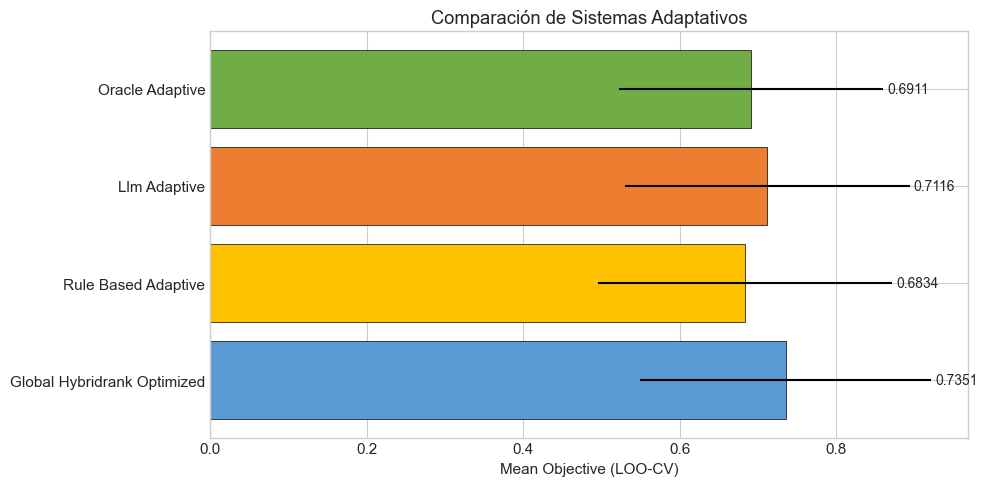

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))

systems_order = ['global_hybridrank_optimized', 'rule_based_adaptive', 'llm_adaptive', 'oracle_adaptive']
systems_present = [s for s in systems_order if s in df_summary['system'].values]
df_plot = df_summary.set_index('system').loc[systems_present]

colors = {'global_hybridrank_optimized': '#5B9BD5', 'oracle_adaptive': '#70AD47',
           'rule_based_adaptive': '#FFC000', 'llm_adaptive': '#ED7D31'}
bar_colors = [colors.get(s, '#999') for s in systems_present]

bars = ax.barh(range(len(systems_present)), df_plot['mean_objective'], 
               xerr=df_plot['std_objective'], color=bar_colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(systems_present)))
ax.set_yticklabels([s.replace('_', ' ').title() for s in systems_present])
ax.set_xlabel('Mean Objective (LOO-CV)')
ax.set_title('Comparación de Sistemas Adaptativos')

for i, (v, s) in enumerate(zip(df_plot['mean_objective'], df_plot['std_objective'])):
    ax.text(v + s + 0.005, i, f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'adaptive_system_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Heatmap de Métricas por Sistema

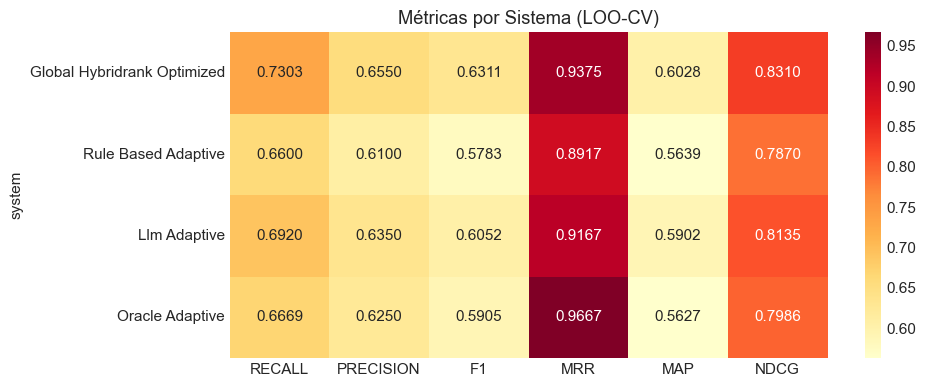

In [38]:
metric_cols = ['mean_recall', 'mean_precision', 'mean_f1', 'mean_mrr', 'mean_map', 'mean_ndcg']
df_heat = df_summary.set_index('system')[metric_cols].loc[systems_present]
df_heat.columns = [c.replace('mean_', '').upper() for c in df_heat.columns]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df_heat, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
            yticklabels=[s.replace('_', ' ').title() for s in systems_present])
ax.set_title('Métricas por Sistema (LOO-CV)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'adaptive_metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Rendimiento por Tipo de Query

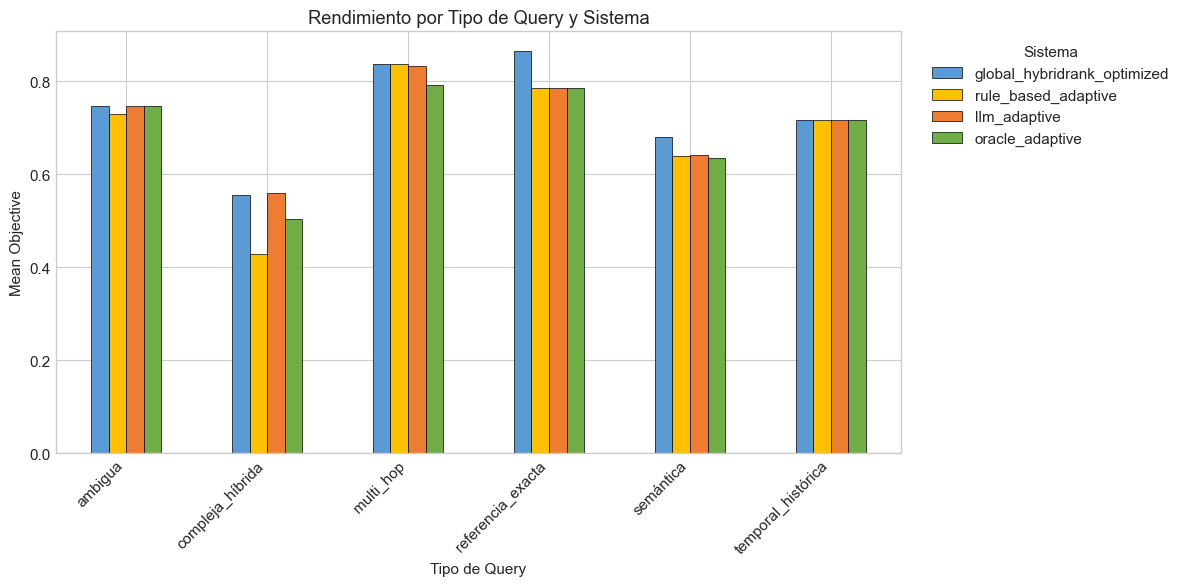


Objective promedio por tipo y sistema:


system,global_hybridrank_optimized,rule_based_adaptive,llm_adaptive,oracle_adaptive
query_type_gold,,,,
ambigua,0.7467,0.7296,0.7467,0.7467
compleja_híbrida,0.5558,0.4292,0.5591,0.5040
multi_hop,0.8367,0.8367,0.8326,0.7929
referencia_exacta,0.8640,0.7851,0.7851,0.7851
semántica,0.6800,0.6397,0.6420,0.6344
temporal_histórica,0.7167,0.7167,0.7167,0.7167


In [39]:
pivot = df_loocv.pivot_table(values='objective', index='query_type_gold', 
                              columns='system', aggfunc='mean')
pivot = pivot[systems_present]

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind='bar', ax=ax, color=[colors.get(s, '#999') for s in systems_present],
           edgecolor='black', linewidth=0.5)
ax.set_ylabel('Mean Objective')
ax.set_xlabel('Tipo de Query')
ax.set_title('Rendimiento por Tipo de Query y Sistema')
ax.legend(title='Sistema', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'adaptive_by_query_type.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nObjective promedio por tipo y sistema:')
display(pivot.round(4))

## 4. Oracle Gap Analysis

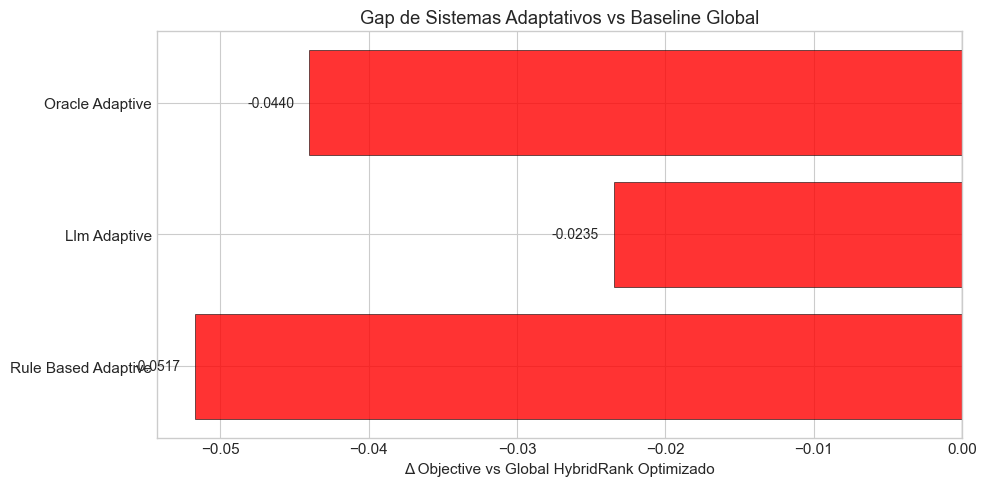


Oracle ceiling: 0.6911
Global baseline: 0.7351
Oracle gap (max improvement possible): -0.0440


In [40]:
global_obj = df_summary[df_summary['system'] == 'global_hybridrank_optimized']['mean_objective'].values[0]

gaps = {}
for s in systems_present:
    if s != 'global_hybridrank_optimized':
        s_obj = df_summary[df_summary['system'] == s]['mean_objective'].values[0]
        gaps[s] = s_obj - global_obj

oracle_obj = df_summary[df_summary['system'] == 'oracle_adaptive']['mean_objective'].values[0] if 'oracle_adaptive' in systems_present else None

fig, ax = plt.subplots(figsize=(10, 5))
gap_names = list(gaps.keys())
gap_values = list(gaps.values())
bar_colors_gap = ['green' if v > 0 else 'red' for v in gap_values]

bars = ax.barh(range(len(gap_names)), gap_values, color=bar_colors_gap, 
               edgecolor='black', linewidth=0.5, alpha=0.8)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_yticks(range(len(gap_names)))
ax.set_yticklabels([s.replace('_', ' ').title() for s in gap_names])
ax.set_xlabel('Δ Objective vs Global HybridRank Optimizado')
ax.set_title('Gap de Sistemas Adaptativos vs Baseline Global')

for i, v in enumerate(gap_values):
    ax.text(v + 0.001 if v >= 0 else v - 0.001, i, f'{v:+.4f}', 
            va='center', ha='left' if v >= 0 else 'right', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'oracle_gap.png', dpi=150, bbox_inches='tight')
plt.show()

if oracle_obj:
    print(f'\nOracle ceiling: {oracle_obj:.4f}')
    print(f'Global baseline: {global_obj:.4f}')
    print(f'Oracle gap (max improvement possible): {oracle_obj - global_obj:+.4f}')
    for s, g in gaps.items():
        if s != 'oracle_adaptive' and oracle_obj > global_obj:
            recovery = g / (oracle_obj - global_obj) * 100
            print(f'{s} recovers {recovery:.1f}% of oracle gap')

## 5. Matriz de Confusión de Clasificadores

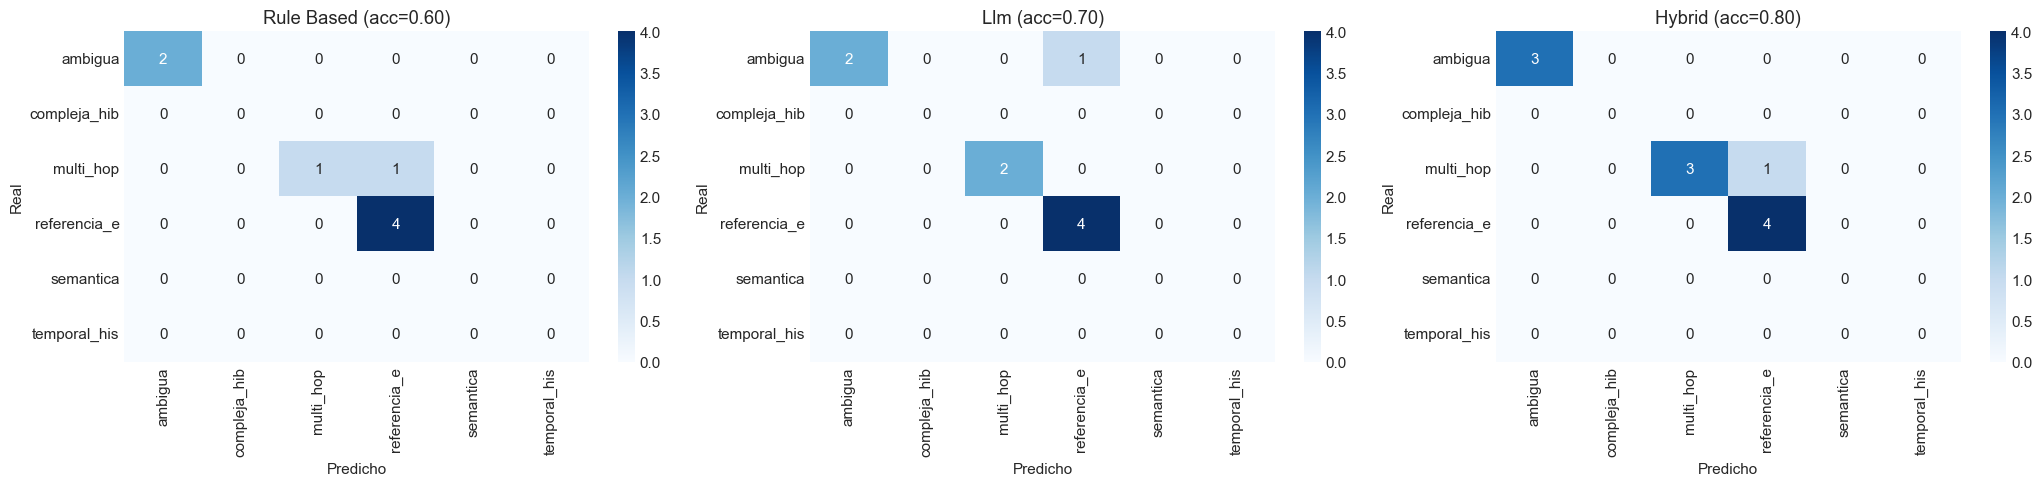

In [41]:
import sys

classifiers_available = []
if 'rule_based_pred' in df_clf.columns:
    classifiers_available.append(('rule_based', 'rule_based_pred'))
if 'llm_pred' in df_clf.columns and df_clf['llm_pred'].notna().any() and (df_clf['llm_pred'] != '').any():
    classifiers_available.append(('llm', 'llm_pred'))
if 'hybrid_pred' in df_clf.columns and df_clf['hybrid_pred'].notna().any() and (df_clf['hybrid_pred'] != '').any():
    classifiers_available.append(('hybrid', 'hybrid_pred'))

# Resolve QUERY_TYPES even when `src` is not installed as a package
QUERY_TYPES = None
try:
    from src.adaptive import QUERY_TYPES  # noqa: F401
except ModuleNotFoundError:
    cwd = Path.cwd().resolve()
    repo_root = next((p for p in [cwd, *cwd.parents] if (p / 'src').exists()), None)
    if repo_root and str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))
    try:
        from src.adaptive import QUERY_TYPES  # noqa: F401
    except ModuleNotFoundError:
        QUERY_TYPES = sorted(
            set(df_clf['gold_query_type'].dropna().unique()).union(
                *[set(df_clf[c].dropna().unique()) for _, c in classifiers_available]
            )
        )

types_sorted = sorted(QUERY_TYPES) if QUERY_TYPES is not None else []

n_clf = len(classifiers_available)
if n_clf > 0 and len(types_sorted) > 0:
    fig, axes = plt.subplots(1, n_clf, figsize=(7 * n_clf, 5))
    if n_clf == 1:
        axes = [axes]

    for ax, (clf_name, pred_col) in zip(axes, classifiers_available):
        cm = pd.DataFrame(0, index=types_sorted, columns=types_sorted)
        valid = df_clf[df_clf[pred_col].notna() & (df_clf[pred_col] != '')]

        for _, row in valid.iterrows():
            gold = row['gold_query_type']
            pred = row[pred_col]
            if gold in types_sorted and pred in types_sorted:
                cm.loc[gold, pred] += 1

        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=[t[:12] for t in types_sorted],
            yticklabels=[t[:12] for t in types_sorted]
        )
        ax.set_xlabel('Predicho')
        ax.set_ylabel('Real')
        accuracy = clf_summary.get(clf_name, {}).get('accuracy', 0)
        ax.set_title(f'{clf_name.replace("_", " ").title()} (acc={accuracy:.2f})')

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'classification_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No hay datos de clasificación disponibles.')

## 6. Configuraciones Seleccionadas por Tipo

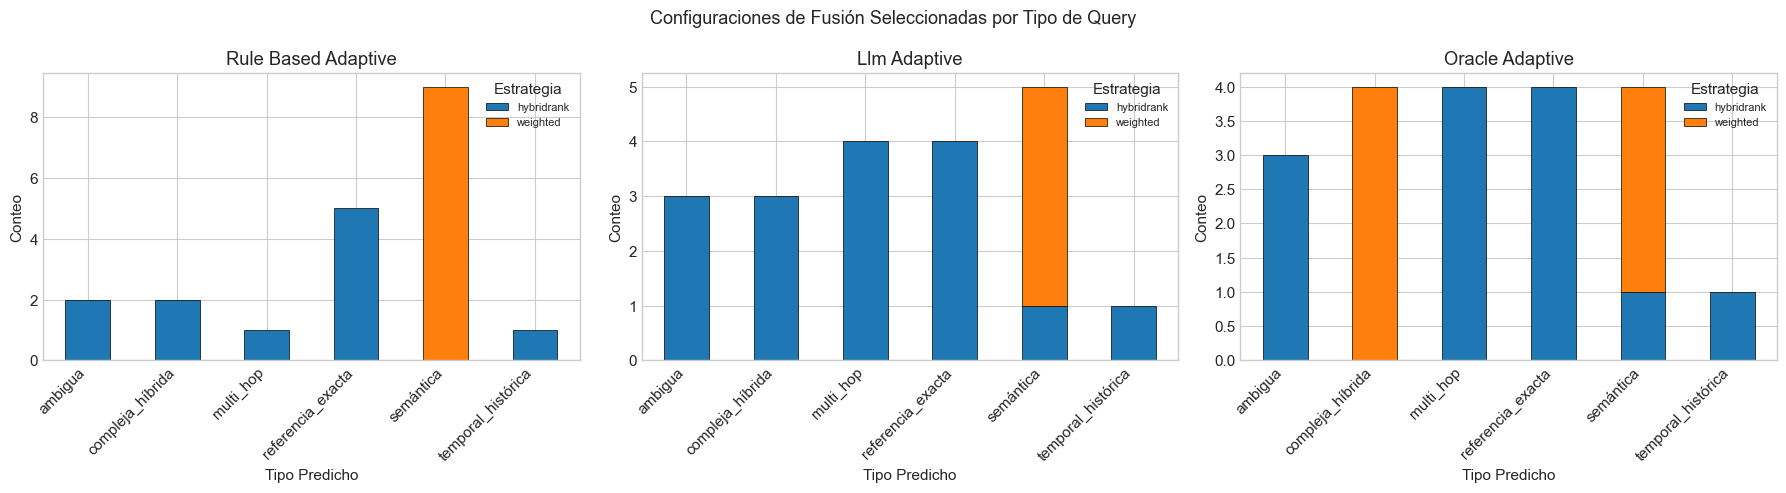


Uso de fallback por sistema y tipo:


predicted_query_type,ambigua,compleja_híbrida,multi_hop,referencia_exacta,semántica,temporal_histórica
system,,,,,,
llm_adaptive,1.0,1.0,0.25,0.0,0.0,1.0
oracle_adaptive,1.0,0.0,0.00,0.0,0.0,1.0
rule_based_adaptive,1.0,1.0,1.00,0.0,0.0,1.0


In [42]:
adaptive_systems = [s for s in systems_present if s != 'global_hybridrank_optimized']
df_adaptive = df_loocv[df_loocv['system'].isin(adaptive_systems)]

fig, axes = plt.subplots(1, len(adaptive_systems), figsize=(6 * len(adaptive_systems), 5))
if len(adaptive_systems) == 1:
    axes = [axes]

for ax, sys_name in zip(axes, adaptive_systems):
    sys_df = df_adaptive[df_adaptive['system'] == sys_name]
    config_counts = sys_df.groupby(['predicted_query_type', 'selected_strategy']).size().unstack(fill_value=0)
    config_counts.plot(kind='bar', stacked=True, ax=ax, edgecolor='black', linewidth=0.5)
    ax.set_title(sys_name.replace('_', ' ').title())
    ax.set_xlabel('Tipo Predicho')
    ax.set_ylabel('Conteo')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.legend(title='Estrategia', fontsize=8)

plt.suptitle('Configuraciones de Fusión Seleccionadas por Tipo de Query', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'adaptive_selected_configs.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla de fallback usage
print('\nUso de fallback por sistema y tipo:')
fallback_table = df_adaptive.pivot_table(values='fallback_used', index='system', 
                                          columns='predicted_query_type', aggfunc='mean')
display(fallback_table.round(2))

## Conclusiones

### Preguntas respondidas:
1. **¿Cuánto mejora oracle_adaptive sobre global?** → Ver gap en sección 4
2. **¿Cuánto recupera rule_based?** → % del oracle gap
3. **¿Cuánto recupera llm_adaptive?** → % del oracle gap
4. **¿Qué errores de clasificación afectan más?** → Matriz de confusión
5. **¿Qué tipos se benefician más?** → Sección 3
6. **¿Cuándo se usa fallback?** → Sección 6